# Linear Regression on advertising dataset

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df = pd.read_csv('advertising.csv') # to load dataset

In [72]:
df.head() # to check the first five rows of the data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [73]:
df.info() # to get the information of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [74]:
df.duplicated().sum() 

np.int64(0)

<Axes: title={'center': 'Box plot for TV'}, xlabel='TV'>

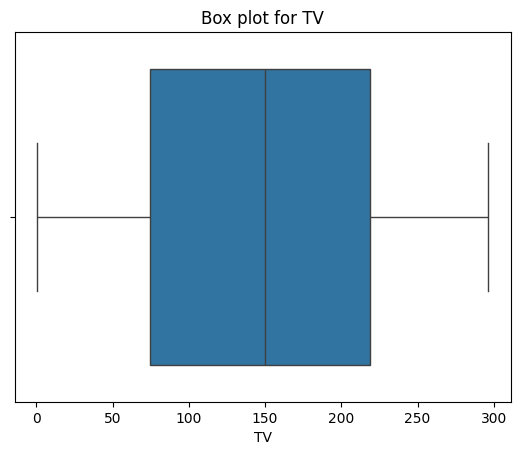

In [75]:
plt.title('Box plot for TV')
sns.boxplot(x=df['TV'])


<Axes: title={'center': 'Box plot for Radio'}, xlabel='Radio'>

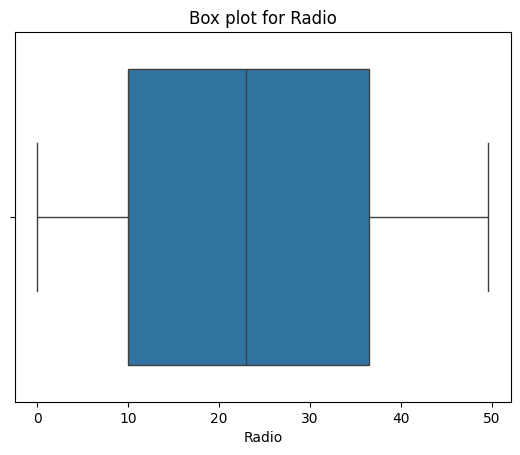

In [76]:
plt.title('Box plot for Radio')
sns.boxplot(x=df['Radio'])

<Axes: title={'center': 'Box plot for Newspaper'}, xlabel='Newspaper'>

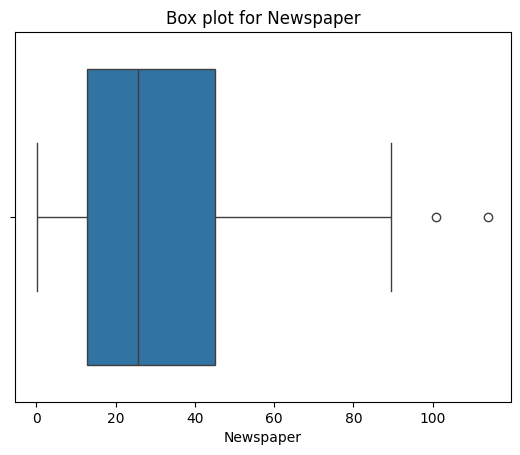

In [77]:
plt.title('Box plot for Newspaper')
sns.boxplot(x=df['Newspaper'])

<Axes: title={'center': 'Box plot for Sales'}, xlabel='Sales'>

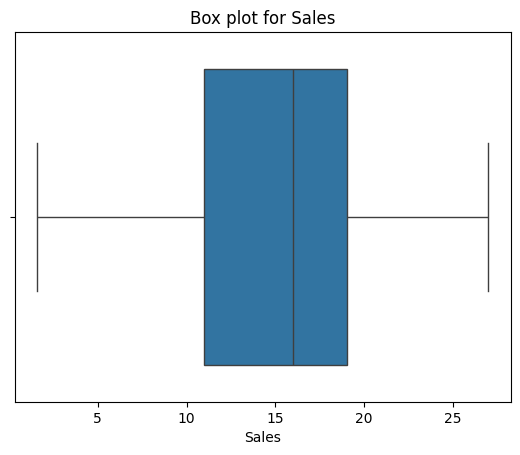

In [78]:
plt.title('Box plot for Sales')
sns.boxplot(x=df['Sales'])

Ouliers is in the newspaper column

Remove outliers using IQR Method

In [79]:
q1 = df['Newspaper'].quantile(0.25)
q3 = df['Newspaper'].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR


In [80]:
upper_bound

np.float64(93.625)

In [81]:
df = df[(df['Newspaper'] >= lower_bound) & (df['Newspaper'] <= upper_bound)]

In [82]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.051978,0.049771,0.899974
Radio,0.051978,1.000000,0.346364,0.348566
Newspaper,0.049771,0.346364,1.000000,0.151764
Sales,0.899974,0.348566,0.151764,1.000000


`TV` has strong positve relation with the Sales column

<Axes: xlabel='TV', ylabel='Sales'>

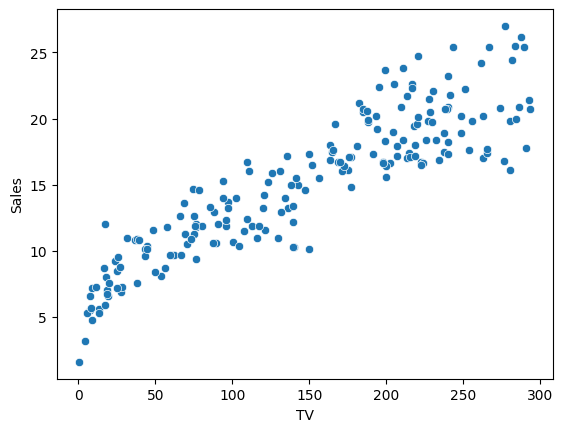

In [84]:
sns.scatterplot(x=df['TV'], y=df['Sales'])

<Axes: xlabel='Radio', ylabel='Sales'>

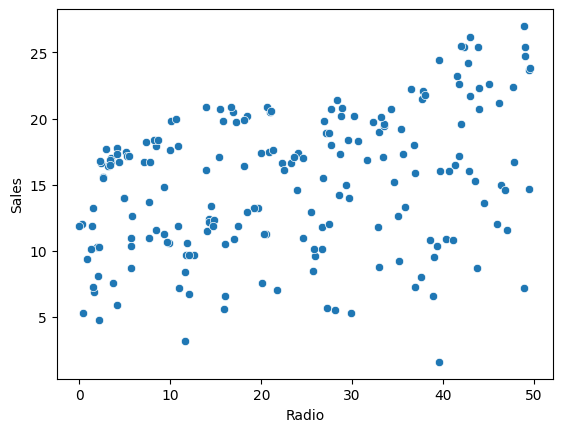

In [85]:
sns.scatterplot(x=df['Radio'], y=df['Sales'])

<Axes: xlabel='Newspaper', ylabel='Sales'>

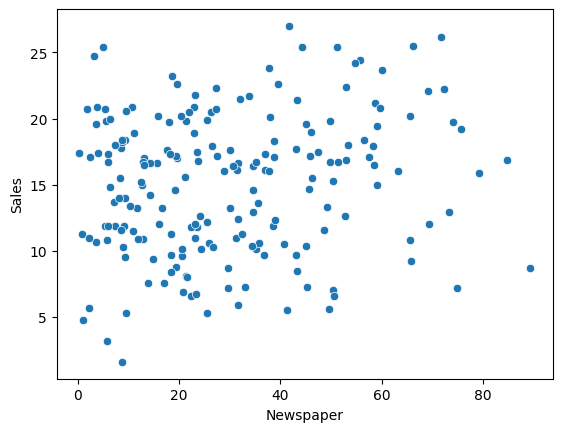

In [86]:
sns.scatterplot(x=df['Newspaper'], y=df['Sales'])

In [87]:
X = df.drop('Sales', axis=1)
y = df.Sales

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [89]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [90]:
model.coef_

array([0.05395925, 0.10101512, 0.00746937])

In [91]:
model.intercept_

np.float64(4.623695319484101)

In [92]:
y_pred_train =  model.predict(X_train)

In [93]:
from sklearn.metrics import mean_squared_error, r2_score

In [94]:
from math import sqrt
sqrt(mean_squared_error(y_train,y_pred_train))

1.6832164139055152

In [95]:
r2_score(y_train,y_pred_train)

0.8973073018699192

In [96]:
y_pred_test = model.predict(X_test)

In [97]:
sqrt(mean_squared_error(y_test, y_pred_test))

1.5542615434969458

In [99]:
r2_score(y_test, y_pred_test)

0.9130003152798273